In [46]:
import pandas as pd

import numpy as np
import scipy.stats as stats
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

import matplotlib.pyplot as plt
import seaborn as sns

from arch import arch_model

from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler, MinMaxScaler

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, GRU, Dropout,Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from statsmodels.stats.diagnostic import acorr_ljungbox

from typing import List, Tuple

sns.set_style("whitegrid")

In [2]:
def create_sequences(
    data: pd.DataFrame,
    lookback: int,
    horizon: int,
    feature_cols: List[str],
    predict_cols: List[str],
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Create input-output sequences for time series forecasting.

    Parameters
    ----------
    data : pd.DataFrame
        Time-ordered dataframe.
    lookback : int
        Number of past timesteps used as input.
    horizon : int
        Number of future timesteps to predict.
    feature_cols : list of str
        Columns used as model inputs.
    predict_cols : list of str
        Columns used as prediction targets.

    Returns
    -------
    X : np.ndarray
        Shape (n_samples, lookback, n_features)
    y : np.ndarray
        Shape (n_samples, horizon, n_targets)
    """

    if lookback <= 0 or horizon <= 0:
        raise ValueError("lookback and horizon must be positive integers")

    missing_features = set(feature_cols) - set(data.columns)
    missing_targets = set(predict_cols) - set(data.columns)
    if missing_features or missing_targets:
        raise ValueError(
            f"Missing columns - features: {missing_features}, targets: {missing_targets}"
        )

    values_X = data[feature_cols].values
    values_y = data[predict_cols].values

    X, y = [], []

    max_start = len(data) - lookback - horizon
    for i in range(max_start):
        X.append(values_X[i : i + lookback])
        y.append(values_y[i + lookback : i + lookback + horizon])

    return np.array(X, dtype=np.float64), np.array(y, dtype=np.float64)

In [3]:
def q_like(realized, predicted):
    div = realized/predicted
    ql = div - np.log(div) - 1
    return np.mean(ql)

In [4]:
data = pd.read_csv(r'../Data/dataset/spy_1min_2008_2021_cleaned.csv', parse_dates=['date'], index_col='date')

## Features Engineering

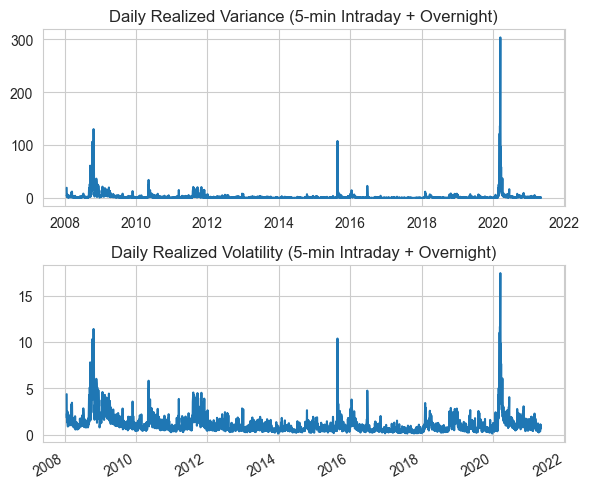

In [5]:

# Intraday Variance
close_5mn = data.close.resample("5min").last().dropna()
rt_intraday = np.log(close_5mn / close_5mn.shift(1)).dropna()
rv_intraday = (rt_intraday ** 2).groupby(rt_intraday.index.date).sum()

# Overnight Variance
daily_ohlc = data.close.resample("1D").agg(['first', 'last']).dropna()
daily_ohlc["prev_close"] = daily_ohlc['last'].shift(1)

# Overnight returns
rt_overnight = np.log(daily_ohlc['first'] / daily_ohlc['prev_close']).dropna()
rv_overnight = rt_overnight ** 2

# Total Realized Variance
rv_total = pd.DataFrame({'intraday': rv_intraday, 'overnight': rv_overnight}).dropna()
rv_total['RV_Daily_Var'] = rv_total['intraday'] + rv_total['overnight']

# Scale to match GARCH (x100^2 = x10000)
target_variance = rv_total['RV_Daily_Var'] * 10000
target_volatility = np.sqrt(target_variance)
target_volatility.index = pd.to_datetime(target_volatility.index)
target_volatility.name = 'RV_Daily_Vol'


fig, ax = plt.subplots(2, 1, figsize=(6,5))
target_variance.plot(title="Daily Realized Variance (5-min Intraday + Overnight)", ax=ax[0])
target_volatility.plot(title="Daily Realized Volatility (5-min Intraday + Overnight)", ax=ax[1])
plt.tight_layout()
plt.show()

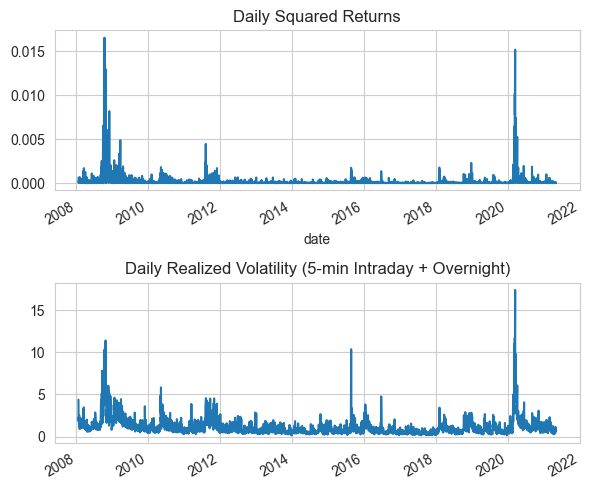

In [6]:
df_daily_close = data.close.resample("1D").last().dropna()
r_daily = np.log(df_daily_close / df_daily_close.shift(1)).dropna()
r_daily.name = "Daily_Return"
r2_daily = r_daily ** 2
r2_daily.name = "Daily_Squared_Return"

fig, ax = plt.subplots(2, 1, figsize=(6,5))
r2_daily.plot(title="Daily Squared Returns", ax=ax[0])
target_volatility.plot(title="Daily Realized Volatility (5-min Intraday + Overnight)", ax=ax[1])
plt.tight_layout()
plt.show()

## Analysis

### Stationarity Test

In [7]:
adfuller_result = adfuller(r_daily)
print("ADF Statistic:", adfuller_result[0])
print("p-value:", adfuller_result[1])
print("Critical Values:")
for key, value in adfuller_result[4].items():
    print(f"   {key}: {value}")

ADF Statistic: -14.315982130207596
p-value: 1.1627203853193956e-26
Critical Values:
   1%: -3.4323164516352445
   5%: -2.8624088629359186
   10%: -2.5672325132363225


### Auto-correlation and Partial Auto-correlation Analysis

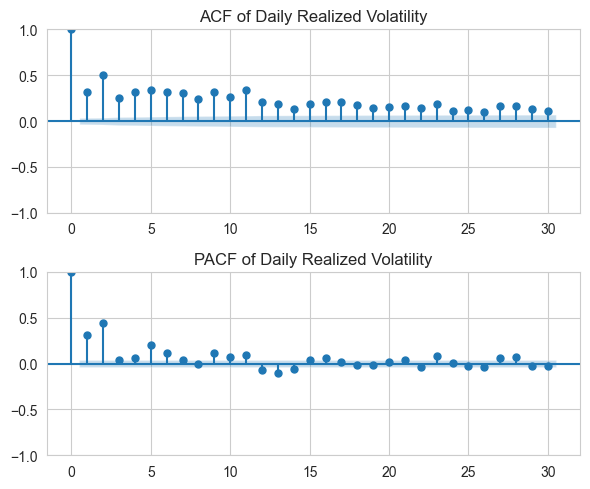

In [8]:
fig, ax = plt.subplots(2, 1, figsize=(6,5))
plot_acf(r2_daily, lags=30, ax=ax[0], title="ACF of Daily Realized Volatility")
plot_pacf(r2_daily, lags=30, ax=ax[1], title="PACF of Daily Realized Volatility")
plt.tight_layout()
plt.show()

### Distribution Analysis

<Axes: title={'center': 'Daily Log Returns'}, ylabel='Frequency'>

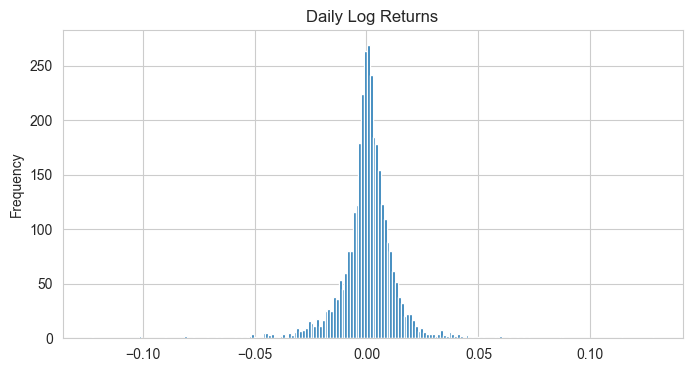

In [9]:
r_daily.plot(title="Daily Log Returns", figsize=(8,4), kind='hist', bins=200)

Distribution parameters:  (np.float64(2.098809399123282), np.float64(0.0009018168160810856), np.float64(0.006305716335320519))


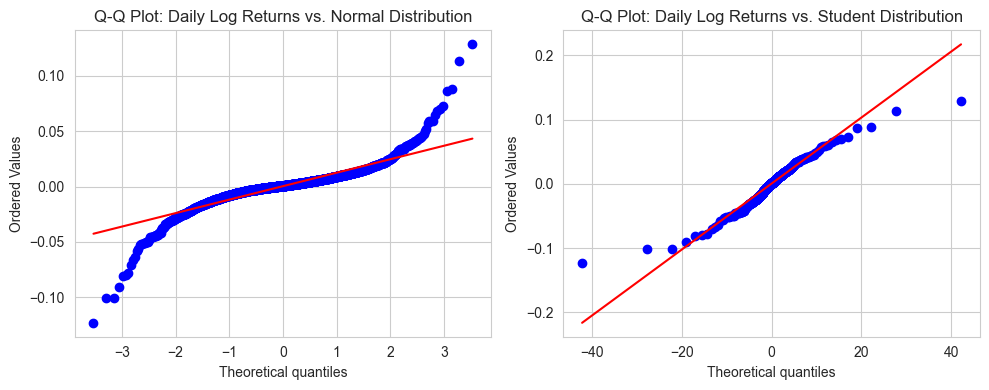

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

params = stats.t.fit(r_daily)
print("Distribution parameters: ",params)

stats.probplot(r_daily, dist="norm", plot=ax[0])
ax[0].set_title("Q-Q Plot: Daily Log Returns vs. Normal Distribution")


stats.probplot(r_daily, dist="t",sparams=(params[0],), plot=ax[1])
ax[1].set_title("Q-Q Plot: Daily Log Returns vs. Student Distribution")

plt.tight_layout()
plt.show()

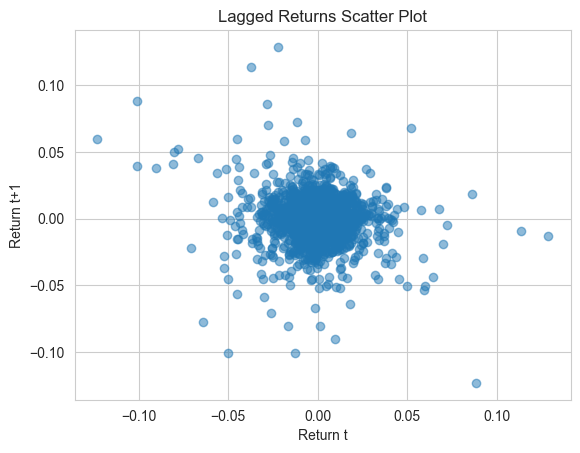

In [11]:
n = 1
plt.plot(r_daily[:-n][:], r_daily[n:][:], 'o', alpha=0.5,)
plt.xlabel('Return t')
plt.ylabel(f'Return t+{n}')
plt.title('Lagged Returns Scatter Plot')
plt.show()

## Data preparation

In [12]:
ration = .9
split_index = int(len(r_daily) * ration)
split_date = r_daily.index[split_index]
print("Train/Test Split Date:", split_date)

Train/Test Split Date: 2020-01-08 00:00:00


## GARCH

In [ ]:
# ar_garch_model = arch_model(
#     returns,
#     mean='AR',       # Change mean model to AutoRegressive
#     lags=2,          # Include Lag 1 and Lag 2
#     vol='Garch',     # The volatility model remains GARCH
#     p=1, q=1,        # Standard GARCH(1,1) parameters
#     dist='StudentT'  # (Optional) Keep your distribution choice
# )

In [143]:
model = arch_model(
    r_daily * 100,
    mean="AR",
    lags=2,
    vol="Garch",
    p=1,
    q=1,
    dist="t",
)
res = model.fit(last_obs=split_date, disp="off")
res.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                              AR - GARCH Model Results                              
====================================================================================
Dep. Variable:                 Daily_Return   R-squared:                       0.006
Mean Model:                              AR   Adj. R-squared:                  0.006
Vol Model:                            GARCH   Log-Likelihood:               -3873.05
Distribution:      Standardized Student's t   AIC:                           7760.10
Method:                  Maximum Likelihood   BIC:                           7802.17
                                              No. Observations:                 3009
Date:                      Thu, Jan 29 2026   Df Residuals:                     3006
Time:                              23:20:01   Df Model:                            3
                                    Mean Model                                   
=================================================================================
                    coef    std err          t      P>|t|        95.0% Conf. Int.
---------------------------------------------------------------------------------
Const             0.0946  1.273e-02      7.429  1.095e-13     [6.962e-02,  0.120]
Dail...urn[1]    -0.0562  1.773e-02     -3.169  1.528e-03 [-9.094e-02,-2.144e-02]
Dail...urn[2]    -0.0266  1.940e-02     -1.373      0.170  [-6.466e-02,1.138e-02]
                              Volatility Model                              
============================================================================
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
omega          0.0164  4.498e-03      3.654  2.579e-04 [7.622e-03,2.525e-02]
alpha[1]       0.1525  2.002e-02      7.617  2.601e-14     [  0.113,  0.192]
beta[1]        0.8475  1.744e-02     48.594      0.000     [  0.813,  0.882]
                              Distribution                              
========================================================================
                 coef    std err          t      P>|t|  95.0% Conf. Int.
------------------------------------------------------------------------
nu             5.1206      0.475     10.774  4.588e-27 [  4.189,  6.052]
========================================================================

Covariance estimator: robust
"""

In [144]:
forecast_horizon = res.forecast(start=r_daily.index[2])
garch_var = forecast_horizon.variance.dropna()
garch_var.columns = ['GARCH_Variance_Forecast']
garch_var.head()

,GARCH_Variance_Forecast
date,
2008-01-25,1.765061
2008-01-28,1.839203
2008-01-29,1.608540
2008-01-30,1.475075
2008-01-31,1.687594


In [145]:
test_target_var = pd.DataFrame(target_variance.loc[garch_var.index])
test_target_var.columns = ['Variance_Target']
test_target_var.index = pd.to_datetime(test_target_var.index)
print(test_target_var.head())

            Variance_Target
date                       
2008-01-25         5.258443
2008-01-28         2.371099
2008-01-29         1.840102
2008-01-30         2.235767
2008-01-31         6.302149


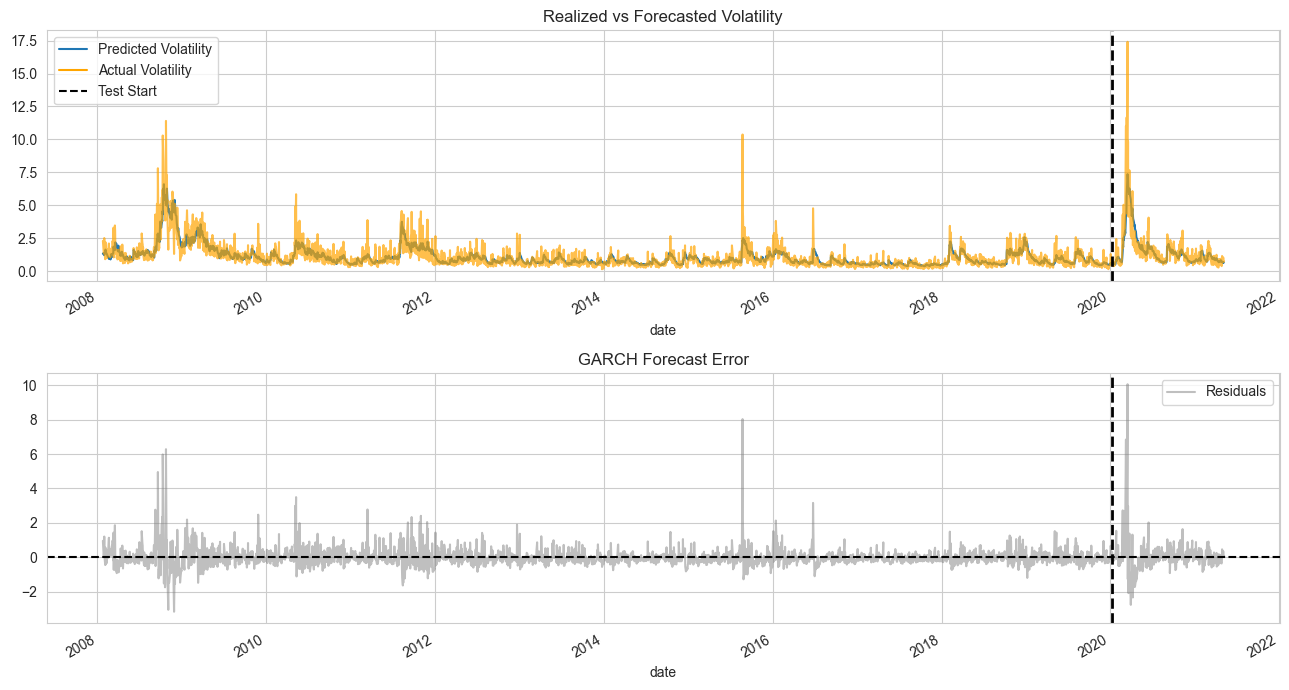

In [146]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.lines as mlines

fig, ax = plt.subplots(2, 1, figsize=(13, 7))

# --- Plot 1 & 2 (Simple) ---
# np.sqrt(garch_var).plot(ax=ax[0], title="GARCH Forecasted Volatility")
# ax[0].legend(["GARCH Forecast"])

# np.sqrt(test_target_var).plot(ax=ax[1], title="Realized Volatility")
# ax[1].legend(["Realized Volatility"])


# --- Plot 3: The Complex Comparison (FIXED) ---
# 1. Plot the data (Note: we don't pass label here, we define it in the legend step)
np.sqrt(garch_var).plot(ax=ax[0], title="Realized vs Forecasted Volatility")
np.sqrt(test_target_var).plot(ax=ax[0], color='orange', alpha=0.7)

# 2. Draw the vertical line
line_split = ax[0].axvline(split_date, color='black', linestyle='--', linewidth=2)

# 3. MANUALLY Create the Legend
# We create "proxy artists" to tell the legend exactly what to show.
# This bypasses any confusion between Pandas and Matplotlib.
blue_line = mlines.Line2D([], [], color='#1f77b4', label='Predicted Volatility') # Default pandas blue
orange_line = mlines.Line2D([], [], color='orange', label='Actual Volatility')
black_line = mlines.Line2D([], [], color='black', linestyle='--', label='Test Start')

ax[0].legend(handles=[blue_line, orange_line, black_line], loc='upper left')


# --- Plot 4: Residuals ---
residuals = np.sqrt(test_target_var["Variance_Target"]) - np.sqrt(garch_var['GARCH_Variance_Forecast'])
residuals.plot(color='gray', alpha=0.5, ax=ax[1])
ax[1].axhline(0, color='black', linestyle='--')
ax[1].set_title("GARCH Forecast Error")
ax[1].legend(["Residuals"])
ax[1].axvline(split_date, color='black', linestyle='--', linewidth=2, label='Test Start')

plt.tight_layout()
plt.show()

In [150]:
print("Evaluation Metrics Naive Model:")
print("     MAE:", mean_absolute_error(np.sqrt(test_target_var[test_target_var.index > split_date]).iloc[1:], np.sqrt(test_target_var[test_target_var.index > split_date]).shift(1).dropna()))
print("     MSE:", mean_squared_error(np.sqrt(test_target_var[test_target_var.index > split_date]).iloc[1:], np.sqrt(test_target_var[test_target_var.index > split_date]).shift(1).dropna()))
print("     QLIKE:", q_like((test_target_var[test_target_var.index > split_date]).iloc[1:].to_numpy(), (test_target_var[test_target_var.index > split_date]).shift(1).dropna().to_numpy()))

print("Evaluation Metrics:")
print("     MAE:", mean_absolute_error(np.sqrt(test_target_var[test_target_var.index > split_date]["Variance_Target"]), np.sqrt(garch_var[garch_var.index > split_date]["GARCH_Variance_Forecast"])))
print("     MSE:", mean_squared_error(np.sqrt(test_target_var[test_target_var.index > split_date]["Variance_Target"]), np.sqrt(garch_var[garch_var.index > split_date]["GARCH_Variance_Forecast"])))
print("     QLIKE:", q_like((test_target_var[test_target_var.index > split_date]["Variance_Target"]).to_numpy(), (garch_var[garch_var.index > split_date]["GARCH_Variance_Forecast"]).to_numpy()))

Evaluation Metrics Naive Model:
     MAE: 0.6315790850908144
     MSE: 1.5831874600642553
     QLIKE: 0.5064822554176154
Evaluation Metrics:
     MAE: 0.5040445531904547
     MSE: 1.007328835369299
     QLIKE: 0.3153400944353528


## Residuals Analysis

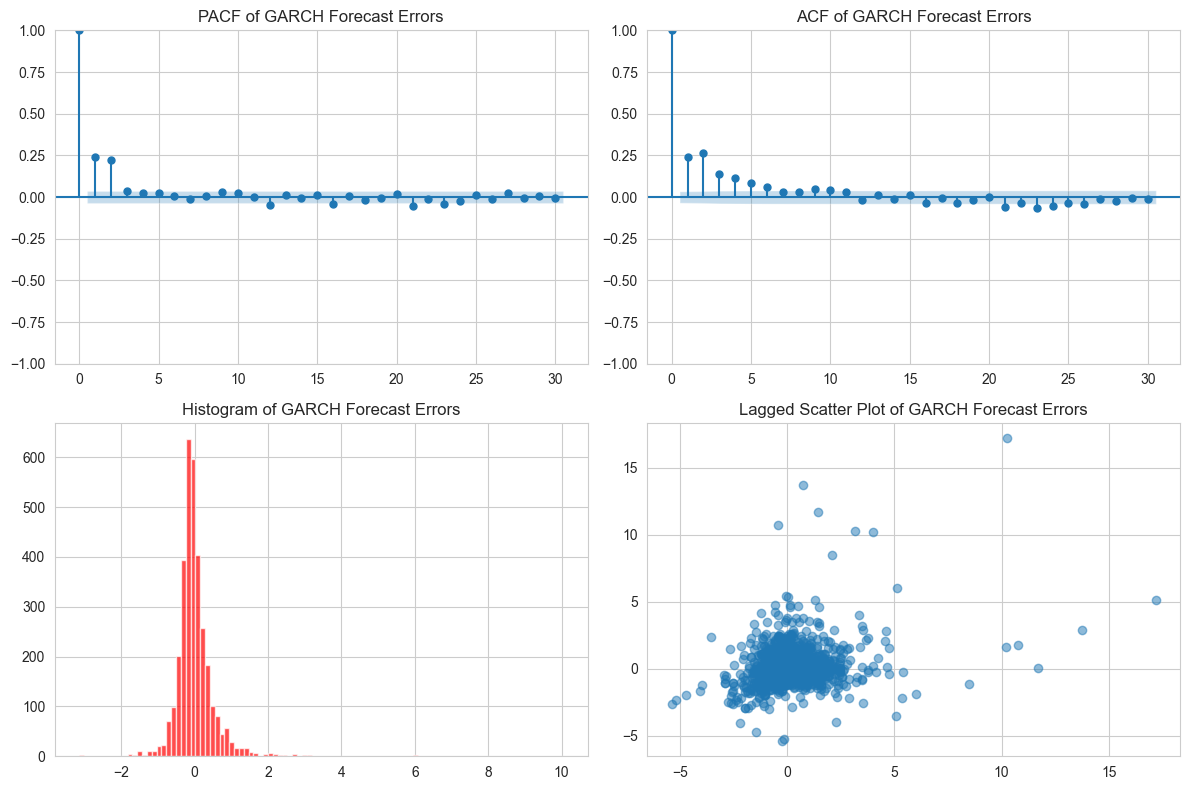

In [151]:
fig, ax = plt.subplots(2, 2, figsize=(12, 8))
plot_pacf(residuals, lags=30, title="PACF of GARCH Forecast Errors", ax=ax[0, 0])
plot_acf(residuals, lags=30, title="ACF of GARCH Forecast Errors", ax=ax[0, 1])

residuals.hist(bins=100, color="red", alpha=0.7, ax=ax[1, 0])
ax[1, 0].set_title("Histogram of GARCH Forecast Errors")

n = 2
ax[1, 1].scatter(
    StandardScaler().fit_transform((residuals[:-2].values.reshape(-1, 1))),
    StandardScaler().fit_transform((residuals[2:].values.reshape(-1, 1))),
    alpha=0.5,
)
ax[1, 1].set_title("Lagged Scatter Plot of GARCH Forecast Errors")

plt.tight_layout()
plt.show()

In [391]:
lb_test = acorr_ljungbox(residuals, lags=[5, 10, 50, 100], return_df=True)

print(lb_test)
# H0 the data is white noise (no autocorrelation) if p-value > 0.05 and model has captured all patterns
# H1 there is autocorrelation present if p-value <= 0.05 and model has not captured all patterns

        lb_stat      lb_pvalue
5    562.966721  2.023881e-119
10   594.640592  2.477339e-121
50   751.438069  7.242546e-126
100  818.981855  2.700238e-113


## GRU Model

In [153]:
gru_entry = pd.DataFrame({"GARCH_Residuals": residuals,})
gru_entry["Daily_Return"] = r_daily
gru_entry["Target_Volatility"] = np.sqrt(test_target_var["Variance_Target"])
gru_entry

,GARCH_Residuals,Daily_Return,Target_Volatility
date,,,
2008-01-25,0.964574,-0.013957,2.293130
2008-01-28,0.183665,0.016178,1.539837
2008-01-29,0.088221,0.005090,1.356504
2008-01-30,0.280721,-0.007682,1.495248
2008-01-31,1.211334,0.017857,2.510408
...,...,...,...
2021-04-30,0.262302,-0.006449,0.954376
2021-05-03,0.112536,0.002083,0.763463
2021-05-04,0.357214,-0.006044,1.028943


In [407]:
HORIZON = 1
LOOKBACK = 20
feature_cols = ["Daily_Return", "Target_Volatility", "GARCH_Residuals"]
predict_cols = ["GARCH_Residuals",]

X_raw, y_raw = create_sequences(
    data=gru_entry,
    lookback=LOOKBACK,
    horizon=HORIZON,
    feature_cols=feature_cols,
    predict_cols=predict_cols,
)


print(f"X shape: {X_raw.shape}  (Samples, Timesteps, Features)")
print(f"y shape: {y_raw.shape}  (Samples, Horizon)")

X shape: (3323, 20, 3)  (Samples, Timesteps, Features)
y shape: (3323, 1, 1)  (Samples, Horizon)


In [408]:
ratio = .9
n_sep = int(ratio * X_raw.shape[0])

X_train, X_test = X_raw[:n_sep], X_raw[n_sep:]
y_train, y_test = y_raw[:n_sep], y_raw[n_sep:]

X_scaler = StandardScaler()
y_scaler = StandardScaler()

X_train_scaled = X_scaler.fit_transform(
    X_train.reshape(-1, X_train.shape[-1])
).reshape(X_train.shape)

X_test_scaled = X_scaler.transform(
    X_test.reshape(-1, X_test.shape[-1])
).reshape(X_test.shape)

y_train_scaled = y_scaler.fit_transform(
    y_train.reshape(-1, y_train.shape[-1])
).reshape(y_train.shape)

y_test_scaled = y_scaler.transform(
    y_test.reshape(-1, y_test.shape[-1])
).reshape(y_test.shape)

print("Data shapes:")
print("Raw Data:")
print(f"Training set: X={X_train.shape}, y={y_train.shape}")
print(f"Test set: X={X_test.shape}, y={y_test.shape}")

print("Scaled Data:")
print(f"Training set: X={X_train_scaled.shape}, y={y_train_scaled.shape}")
print(f"Test set: X={X_test_scaled.shape}, y={y_test_scaled.shape}")

Data shapes:
Raw Data:
Training set: X=(2990, 20, 3), y=(2990, 1, 1)
Test set: X=(333, 20, 3), y=(333, 1, 1)
Scaled Data:
Training set: X=(2990, 20, 3), y=(2990, 1, 1)
Test set: X=(333, 20, 3), y=(333, 1, 1)


In [409]:
INPUT_SHAPE = (X_train.shape[1], X_train.shape[2])
OUTPUT_SIZE = y_train.shape[1]

print(f"Input shape: {INPUT_SHAPE}")
print(f"Output size: {OUTPUT_SIZE}")

Input shape: (20, 3)
Output size: 1


In [ ]:
model = Sequential(
    [
        Input(shape=INPUT_SHAPE),
        GRU(units=64, return_sequences=False, activation="tanh", recurrent_dropout=0.0),
        Dropout(0.3),
        Dense(32, activation="relu"),
        Dense(OUTPUT_SIZE, activation="linear"),
    ]
)

model.compile(optimizer="adam", loss="mae", metrics=["mae"])

model.summary()

callbacks = [
    EarlyStopping(monitor="val_loss", patience=15, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5, verbose=1)
]

Model: "sequential_20"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_20 (GRU)                    │ (None, 128)            │        51,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_40 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 59,393 (232.00 KB)

 Trainable params: 59,393 (232.00 KB)

 Non-trainable params: 0 (0.00 B)

In [421]:
history = model.fit(
    X_train_scaled, y_train_scaled,
    validation_data=(X_test_scaled, y_test_scaled),
    epochs=100,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 0.5568 - mae: 0.5568 - val_loss: 0.9060 - val_mae: 0.9060 - learning_rate: 0.0010
Epoch 2/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.5459 - mae: 0.5459 - val_loss: 0.9171 - val_mae: 0.9171 - learning_rate: 0.0010
Epoch 3/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - loss: 0.5432 - mae: 0.5432 - val_loss: 0.8896 - val_mae: 0.8896 - learning_rate: 0.0010
Epoch 4/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - loss: 0.5362 - mae: 0.5362 - val_loss: 0.9046 - val_mae: 0.9046 - learning_rate: 0.0010
Epoch 5/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.5354 - mae: 0.5354 - val_loss: 0.8881 - val_mae: 0.8881 - learning_rate: 0.0010
Epoch 6/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - loss: 0.5338 - mae: 0.5338 - val_loss: 0.8852 - val_mae: 0.8852 - learning_rate: 0.0010
Epoch 7/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.5284 - mae: 0.5284 - val_loss: 0.8911 - val_mae: 0.8911 - learning_rate: 0.0010
Epoch 

In [422]:
y_pred_scaled: np.ndarray = model.predict(X_test_scaled)

y_pred = y_scaler.inverse_transform(
    y_pred_scaled.reshape(-1, y_test.shape[-1])
).reshape(y_pred_scaled.shape)

y_true = y_scaler.inverse_transform(
    y_test_scaled.reshape(-1, y_test.shape[-1])
).reshape(y_test_scaled.shape)

pred_label = "Predicted_Variance"
true_label = "Actual_Variance"

AR_GARCH_LAG = 2
y_pred_df = pd.DataFrame(
    (y_pred)[:, 0], index=r_daily.index[LOOKBACK + n_sep + AR_GARCH_LAG : -HORIZON], columns=[pred_label]
)
y_true_df = pd.DataFrame(
    (y_true)[:, 0], index=r_daily.index[LOOKBACK + n_sep + AR_GARCH_LAG : -HORIZON], columns=[true_label]
)

11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step


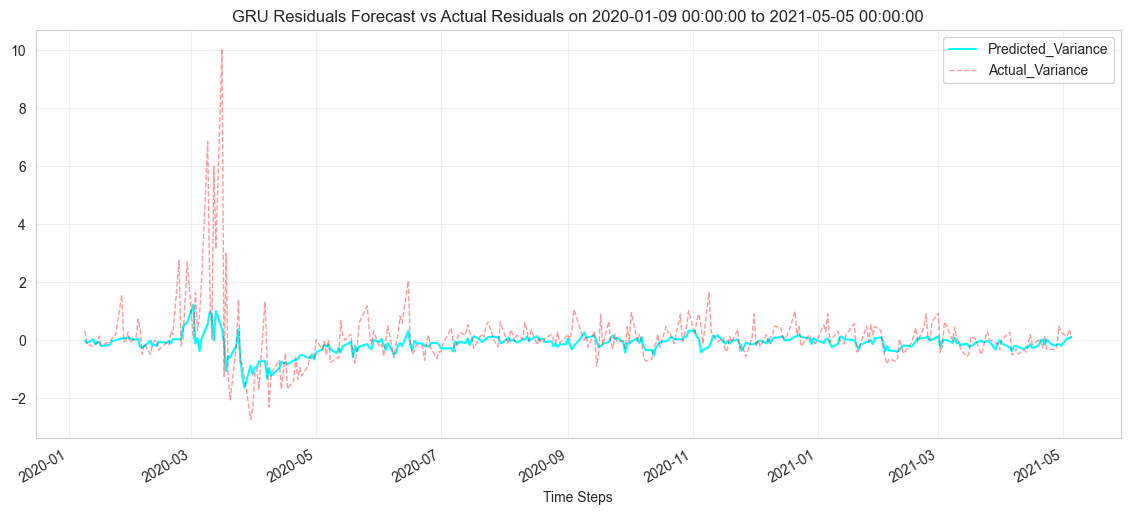

In [423]:
fig, ax = plt.subplots( figsize=(14, 6))
y_pred_df.plot(ax=ax, color="cyan", legend=True)
y_true_df.plot(ax=ax, color="red", linewidth=1, linestyle="--", legend=True, alpha=0.4)

plt.title(
    f"GRU Residuals Forecast vs Actual Residuals on {y_pred_df.index[0]} to {y_pred_df.index[-1]}"
)
plt.xlabel("Time Steps")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [424]:
vol_res_back = np.sqrt(garch_var[(garch_var.index >= y_pred_df.index[0]) & (garch_var.index <= y_pred_df.index[-1])]["GARCH_Variance_Forecast"]).values + y_pred_df.values.ravel()
# vol_res_back

In [425]:
real_vol_target = np.sqrt(test_target_var[(test_target_var.index >= y_pred_df.index[0]) & (test_target_var.index <= y_pred_df.index[-1])]["Variance_Target"])
# real_vol_target

In [426]:
fin_df = pd.DataFrame(
    {
        "Hybrid_Volatility_Forecast": vol_res_back,
        "Realized_Volatility": real_vol_target.values,
        "Garch_volatility_Forecast": np.sqrt(garch_var[(garch_var.index >= y_pred_df.index[0]) & (garch_var.index <= y_pred_df.index[-1])]["GARCH_Variance_Forecast"]).values,
    },
    index=real_vol_target.index,
)

fin_df.head()

,Hybrid_Volatility_Forecast,Realized_Volatility,Garch_volatility_Forecast
date,,,
2020-01-09,0.558574,0.890931,0.588781
2020-01-10,0.459644,0.435188,0.571252
2020-01-13,0.608841,0.371226,0.589701
2020-01-14,0.412628,0.421070,0.564315
2020-01-15,0.471632,0.398463,0.537667


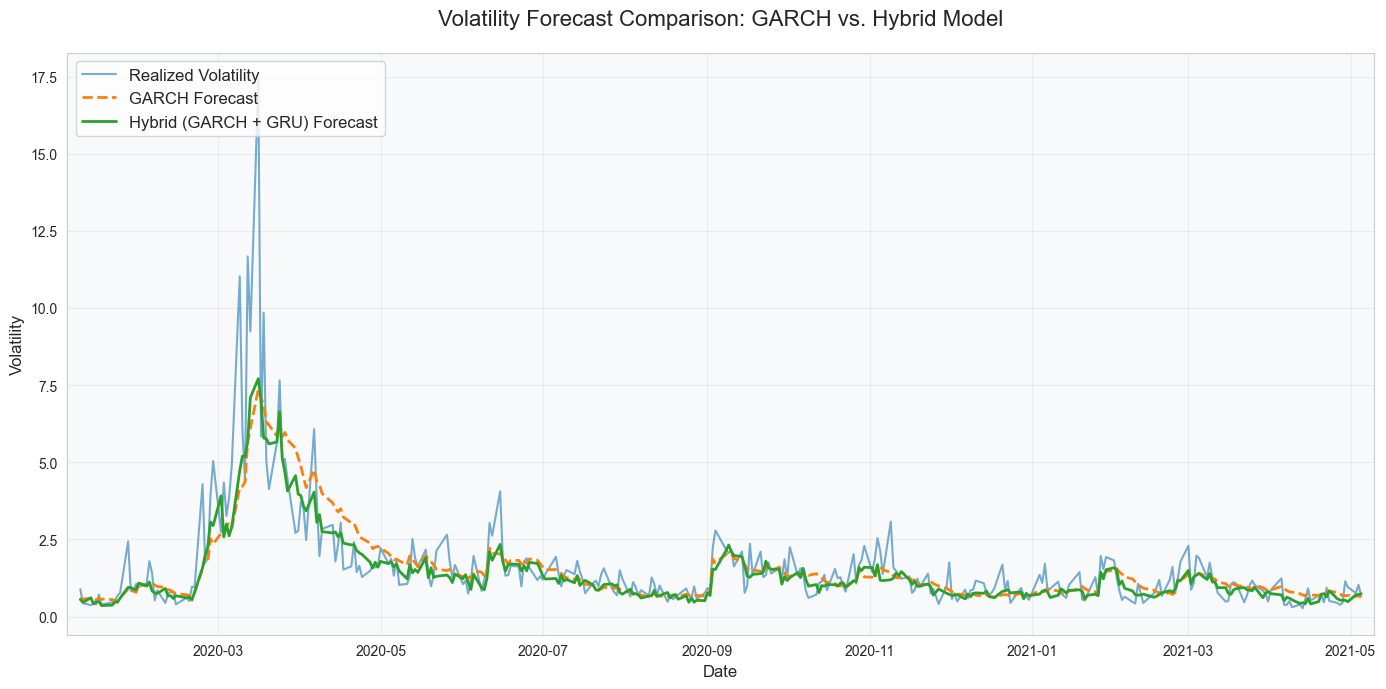

In [427]:
# Create a professional plot for the volatility forecasts
plt.figure(figsize=(14, 7))

# Plot Realized Volatility
plt.plot(fin_df.index, fin_df['Realized_Volatility'], 
         label='Realized Volatility', color='#1f77b4', alpha=0.6, linewidth=1.5)

# Plot GARCH Forecast
plt.plot(fin_df.index, fin_df['Garch_volatility_Forecast'], 
         label='GARCH Forecast', color='#ff7f0e', linestyle='--', linewidth=2)

# Plot Hybrid Forecast
plt.plot(fin_df.index, fin_df['Hybrid_Volatility_Forecast'], 
         label='Hybrid (GARCH + GRU) Forecast', color='#2ca02c', linewidth=2)

# Formatting
plt.title('Volatility Forecast Comparison: GARCH vs. Hybrid Model', fontsize=16, pad=20)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Volatility', fontsize=12)
plt.legend(fontsize=12, loc='upper left')
plt.grid(True, alpha=0.3)
plt.margins(x=0.01)

# Add a subtle background color for better readability
plt.gca().set_facecolor('#f8f9fa')

plt.tight_layout()
plt.show()

In [428]:
print("Evaluation Metrics Naive Model:")
print("     MAE:", mean_absolute_error(np.sqrt(test_target_var[test_target_var.index > split_date]).iloc[1:], np.sqrt(test_target_var[test_target_var.index > split_date]).shift(1).dropna()))
print("     MSE:", mean_squared_error(np.sqrt(test_target_var[test_target_var.index > split_date]).iloc[1:], np.sqrt(test_target_var[test_target_var.index > split_date]).shift(1).dropna()))
print("     QLIKE:", q_like((test_target_var[test_target_var.index > split_date]).iloc[1:].to_numpy(), (test_target_var[test_target_var.index > split_date]).shift(1).dropna().to_numpy()))

print("Evaluation Metrics on GARCH:")
print("     MAE:", mean_absolute_error(np.sqrt(test_target_var[test_target_var.index > split_date]["Variance_Target"]), np.sqrt(garch_var[garch_var.index > split_date]["GARCH_Variance_Forecast"])))
print("     MSE:", mean_squared_error(np.sqrt(test_target_var[test_target_var.index > split_date]["Variance_Target"]), np.sqrt(garch_var[garch_var.index > split_date]["GARCH_Variance_Forecast"])))
print("     QLIKE:", q_like((test_target_var[test_target_var.index > split_date]["Variance_Target"]).to_numpy(), (garch_var[garch_var.index > split_date]["GARCH_Variance_Forecast"]).to_numpy()))

print("Evaluation Metrics on GARCH + GRU Residuals:")
print("     MAE:", mean_absolute_error(vol_res_back, real_vol_target))
print("     MSE:", mean_squared_error(vol_res_back, real_vol_target))
print("     QLIKE:", q_like(vol_res_back**2, real_vol_target**2))

Evaluation Metrics Naive Model:
     MAE: 0.6315790850908144
     MSE: 1.5831874600642553
     QLIKE: 0.5064822554176154
Evaluation Metrics on GARCH:
     MAE: 0.5040445531904547
     MSE: 1.007328835369299
     QLIKE: 0.3153400944353528
Evaluation Metrics on GARCH + GRU Residuals:
     MAE: 0.44542525075869077
     MSE: 0.8540134311270581
     QLIKE: 0.23299411649807386


In [419]:

# GARCH Student AR + GRU, W = 40, SPLIT 90/10, FEATURES: DAILY RETURN, TARGET VOLATILITY, GARCH_RESIDUALS 
# Evaluation Metrics on GARCH:
#      MAE: 0.5040445531904547
#      MSE: 1.007328835369299
#      QLIKE: 0.3153400944353528
# Evaluation Metrics on GARCH + GRU Residuals:
#      MAE: 0.4407273123891271
#      MSE: 0.8036358264883652
#      QLIKE: 0.22908202269349862
# GARCH Student AR + GRU, W = 30, SPLIT 90/10, FEATURES: DAILY RETURN, TARGET VOLATILITY, GARCH_RESIDUALS 
# Evaluation Metrics on GARCH:
#      MAE: 0.5040445531904547
#      MSE: 1.007328835369299
#      QLIKE: 0.3153400944353528
# Evaluation Metrics on GARCH + GRU Residuals:
#      MAE: 0.4496758897998916
#      MSE: 0.8655578260294944
#      QLIKE: 0.22433328123820223
# GARCH Student AR + GRU, W = 50, SPLIT 90/10, FEATURES: DAILY RETURN, TARGET VOLATILITY, GARCH_RESIDUALS 
# Evaluation Metrics on GARCH:
#      MAE: 0.5040445531904547
#      MSE: 1.007328835369299
#      QLIKE: 0.3153400944353528
# Evaluation Metrics on GARCH + GRU Residuals:
#      MAE: 0.4530103565767216
#      MSE: 0.8742548114160567
#      QLIKE: 0.23022448203497803
# GARCH Student AR + GRU, W = 20, SPLIT 90/10, FEATURES: DAILY RETURN, TARGET VOLATILITY, GARCH_RESIDUALS 
# Evaluation Metrics on GARCH:
#      MAE: 0.5040445531904547
#      MSE: 1.007328835369299
#      QLIKE: 0.3153400944353528
# Evaluation Metrics on GARCH + GRU Residuals:
#      MAE: 0.44999493431728466
#      MSE: 0.872367274417298
#      QLIKE: 0.23158645809856038
# GARCH Student AR + GRU, W = 20, SPLIT 90/10, FEATURES: DAILY RETURN + TARGET VOLATILITY
# Evaluation Metrics on GARCH + GRU Residuals:
#      MAE: 0.44166456731447096
#      MSE: 0.8289796340972136
#      QLIKE: 0.27489518705113125

# GARCH Student + GRU, W = 20, SPLIT 90/10, FEATURES: DAILY RETURN + TARGET VOLATILITY
# Evaluation Metrics on GARCH:
#      MAE: 0.5067891743795462
#      MSE: 1.001419247285357
#      QLIKE: 0.3181014531513183
# Evaluation Metrics on GARCH + GRU Residuals:
#      MAE: 0.4462840309650657
#      MSE: 0.9082245053129974
#      QLIKE: 0.2470666225533685
# GARCH Student + GRU, W = 100, SPLIT 90/10, FEATURES: GARCH RESIDUALS + DAILY RETURN + TARGET VOLATILITY
# Evaluation Metrics on GARCH:
#      MAE: 0.5067891743795462
#      MSE: 1.001419247285357
#      QLIKE: 0.3181014531513183
# Evaluation Metrics on GARCH + GRU Residuals:
#      MAE: 0.4516838886283949
#      MSE: 0.8855685029755811
#      QLIKE: 0.23293879059226233
# GARCH Student + GRU, W = 30, SPLIT 90/10, FEATURES: GARCH RESIDUALS + DAILY RETURN + TARGET VOLATILITY
# Evaluation Metrics on GARCH:
#      MAE: 0.5067891743795462
#      MSE: 1.001419247285357
#      QLIKE: 0.3181014531513183
# Evaluation Metrics on GARCH + GRU Residuals:
#      MAE: 0.44903394539646985
#      MSE: 0.8676508123549944
#      QLIKE: 0.23252417660167987
# GARCH Student + GRU, W = 20, SPLIT 90/10, FEATURES: GARCH RESIDUALS + DAILY RETURN + TARGET VOLATILITY
# Evaluation Metrics on GARCH:
#      MAE: 0.5067891743795462
#      MSE: 1.001419247285357
#      QLIKE: 0.3181014531513183
# Evaluation Metrics on GARCH + GRU Residuals:
#      MAE: 0.4414694282826947
#      MSE: 0.8737777617209409
#      QLIKE: 0.24584773169012844

# GARCH Student + GRU, W = 10, SPLIT 90/10, FEATURES: GARCH RESIDUALS + DAILY RETURN + TARGET VOLATILITY
# Evaluation Metrics on GARCH:
#      MAE: 0.5067891743795462
#      MSE: 1.001419247285357
#      QLIKE: 0.3181014531513183
# Evaluation Metrics on GARCH + GRU Residuals:
#      MAE: 0.43765858843419886
#      MSE: 0.7458057610555326
#      QLIKE: 0.2656981782413221

# GARCH Student + GRU, W = 10, SPLIT 90/10, FEATURES: GARCH RESIDUALS + DAILY RETURN
# Evaluation Metrics on GARCH:
#      MAE: 0.5067891743795462
#      MSE: 1.001419247285357
#      QLIKE: 0.3181014531513183
# Evaluation Metrics on GARCH + GRU Residuals:
#      MAE: 0.43571910836981853
#      MSE: 0.8331072910354034
#      QLIKE: 0.24899200169346422

## ONLY ONE FEATURE GRU (RESIDUALS)
# GARCH STUDENT + GRU, W = 10, SPLIT 90/10
# Evaluation Metrics Naive Model:
#      MAE: 0.6315790850908144
#      MSE: 1.5831874600642553
#      QLIKE: 0.5064822554176154
# Evaluation Metrics on GARCH:
#      MAE: 0.5067891743795462
#      MSE: 1.001419247285357
#      QLIKE: 0.3181014531513183
# Evaluation Metrics on GARCH + GRU Residuals:
#      MAE: 0.4626851659063404
#      MSE: 0.8435887348856335
#      QLIKE: 0.3041789290151227

# GARCH STUDENT + GRU, W = 20, SPLIT 90/10
# Evaluation Metrics on GARCH:
#      MAE: 0.5067891743795462
#      MSE: 1.001419247285357
#      QLIKE: 0.3181014531513183
# Evaluation Metrics on GARCH + GRU Residuals:
#      MAE: 0.46746136401004834
#      MSE: 0.8149615512470919
#      QLIKE: 0.30757352814465655

# GARCH GAUSSIAN + GRU, W = 20, SPLIT 90/10
# Evaluation Metrics on GARCH:
#      MAE: 0.48756717368098396
#      MSE: 0.9824804599287948
#      QLIKE: 0.32638104744444435
# Evaluation Metrics on GARCH + GRU Residuals:
#      MAE: 0.4647022508139141
#      MSE: 0.8006221147267334
#      QLIKE: 0.3227423770250897

# GARCH STUDENT AR MEAN, W = 20, SPLIT 90/10
# Evaluation Metrics on GARCH:
#      MAE: 0.5040445531904547
#      MSE: 1.007328835369299
#      QLIKE: 0.3153400944353528

| GARCH Configuration | Window (W) | Features Used in GRU                     | Model Type        | MAE    | MSE    | QLIKE |
|--------------------------|------------|-----------------------------------|-------------------|--------|--------|-------|
| GARCH Student AR            | 20        | Return + Target Vol      | GARCH + GRU    | 0.4462 | 0.9082 | 0.2470 |
| GARCH Student AR            | -        | -      | GARCH    | 0.5040 | 1.0073 | 0.3153 |
| GARCH Student            | -        | -      | GARCH    | 0.5068 | 1.0014 | 0.3181 |
| GARCH Student            | 100        | Resids + Return + Target Vol      | GARCH + GRU       | 0.4517 | 0.8856 | 0.2329 |
| GARCH Student            | -         | -      | GARCH    | 0.5068 | 1.0014 | 0.3181 |
| GARCH Student            | 30         | Resids + Return + Target Vol      | GARCH + GRU       | 0.4490 | 0.8677 | 0.2325 |
| GARCH Student            | -         | -      | GARCH    | 0.5068 | 1.0014 | 0.3181 |
| GARCH Student            | 20         | Resids + Return + Target Vol      | GARCH + GRU       | 0.4415 | 0.8738 | 0.2458 |
| GARCH Student            | -         | -      | GARCH    | 0.5068 | 1.0014 | 0.3181 |
| GARCH Student            | 10         | Resids + Return + Target Vol      | GARCH + GRU       | 0.4377 | 0.7458 | 0.2657 |
| GARCH Student            | -         | -                  | GARCH    | 0.5068 | 1.0014 | 0.3181 |
| GARCH Student            | 10         | Resids + Return                  | GARCH + GRU       | 0.4357 | 0.8331 | 0.2490 |
| GARCH Student            | -| -                  | GARCH    | 0.5068 | 1.0014 | 0.3181 |
| GARCH Student            | 10         | Only Residuals                  | GARCH + GRU       | 0.4627 | 0.8436 | 0.3042 |
| GARCH Student            | -| -                  | GARCH    | 0.5068 | 1.0014 | 0.3181 |
| GARCH Student            | 20         | Only Residuals                  | GARCH + GRU       | 0.4675 | 0.8150 | 0.3076 |
| GARCH Gaussian           | 20         | Only Residuals                  | Naive Model       | 0.6316 | 1.5832 | 0.5065 |
| GARCH Gaussian           | -| -                  | GARCH    | 0.4876 | 0.9825 | 0.3264 |
| GARCH Gaussian           | 20         | Only Residuals                  | GARCH + GRU       | 0.4647 | 0.8006 | 0.3227 |
